In [4]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [11]:
DATA_ROOT = Path(r"C:\Users\Niraj Mhatre\projects\motor_insurance_data\Data\CarDD_release\CarDD_release")
COCO_DIR = DATA_ROOT / "CarDD_COCO"
ANNOTATION_DIR = COCO_DIR / "annotations"


annotation_file = ANNOTATION_DIR / "instances_train2017.json"   

In [7]:
annotation_files = list(ANNOTATION_DIR.glob("*.json"))

for file in annotation_files:
    print(file.name)

instances_test2017.json
instances_train2017.json
instances_val2017.json


In [12]:
train_annotation_file = ANNOTATION_DIR / "instances_train2017.json"
val_annotation_file = ANNOTATION_DIR / "instances_val2017.json"

with open(train_annotation_file, "r") as file:
    train_data = json.load(file)

with open(val_annotation_file, "r") as file:
    val_data = json.load(file)

In [13]:
print("Categories:")

for category in train_data["categories"]:
    print(category["id"], ":", category["name"])

Categories:
1 : dent
2 : scratch
3 : crack
4 : glass shatter
5 : lamp broken
6 : tire flat


In [14]:
category_dict = {}

for category in train_data["categories"]:
    category_dict[category["id"]] = category["name"]

print(category_dict)

{1: 'dent', 2: 'scratch', 3: 'crack', 4: 'glass shatter', 5: 'lamp broken', 6: 'tire flat'}


In [16]:
image_categories = {}

for annotation in train_data["annotations"]:

    image_id = annotation["image_id"]
    category_id = annotation["category_id"]

    if image_id not in image_categories:
        image_categories[image_id] = set()

    image_categories[image_id].add(category_id)

In [17]:
multi_label_images = []

for image_id, categories in image_categories.items():

    if len(categories) > 1:
        multi_label_images.append(image_id)

print("Images with more than one damage category:",
      len(multi_label_images))

print("Total annotated images:",
      len(image_categories))

Images with more than one damage category: 1084
Total annotated images: 2816


In [18]:
#creating image to filename mapping
def create_image_dict(data):

    image_dict = {}

    for image in data["images"]:
        image_dict[image["id"]] = image["file_name"]

    return image_dict

In [19]:
train_image_dict = create_image_dict(train_data)
val_image_dict = create_image_dict(val_data)

In [20]:
#creating targets
def create_targets(data, num_classes):

    targets = {}

    for image in data["images"]:

        image_id = image["id"]

        targets[image_id] = np.zeros(
            num_classes,
            dtype=np.float32
        )

    for annotation in data["annotations"]:

        image_id = annotation["image_id"]
        category_id = annotation["category_id"]

        # Find the position of this category
        category_index = list(category_dict.keys()).index(category_id)

        targets[image_id][category_index] = 1.0

    return targets

In [21]:
train_targets = create_targets(
    train_data,
    num_classes
)

val_targets = create_targets(
    val_data,
    num_classes
)

In [22]:
#inspecting targets
for image_id in list(train_targets.keys())[:10]:

    print(
        train_image_dict[image_id],
        "->",
        train_targets[image_id]
    )

000001.jpg -> [0. 1. 0. 0. 0. 1.]
000002.jpg -> [0. 0. 0. 0. 0. 1.]
000003.jpg -> [0. 0. 0. 0. 0. 1.]
000004.jpg -> [0. 0. 0. 0. 0. 1.]
000005.jpg -> [0. 0. 0. 0. 0. 1.]
000006.jpg -> [0. 0. 0. 0. 0. 1.]
000007.jpg -> [0. 0. 0. 0. 0. 1.]
000008.jpg -> [0. 0. 1. 0. 0. 1.]
000009.jpg -> [1. 1. 0. 0. 0. 1.]
000010.jpg -> [0. 0. 0. 0. 0. 1.]


In [23]:
#target distbn for class imbalance
train_target_array = np.array(
    list(train_targets.values())
)

class_counts = train_target_array.sum(axis=0)

for i, category_id in enumerate(category_dict.keys()):

    print(
        category_dict[category_id],
        ":",
        int(class_counts[i])
    )

dent : 1242
scratch : 1507
crack : 434
glass shatter : 469
lamp broken : 489
tire flat : 219


In [24]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

In [25]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(
        224,
        scale=(0.9, 1.0)
    ),
    transforms.ColorJitter(
        brightness=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

In [26]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

In [27]:
class CarDDDataset(Dataset):

    def __init__(
        self,
        image_dir,
        data,
        transform=None
    ):

        self.image_dir = Path(image_dir)
        self.transform = transform

        self.images = data["images"]

        self.targets = {}

        # Initially every image gets an all-zero target
        for image in self.images:

            image_id = image["id"]

            self.targets[image_id] = np.zeros(
                num_classes,
                dtype=np.float32
            )

        # Add labels from annotations
        for annotation in data["annotations"]:

            image_id = annotation["image_id"]
            category_id = annotation["category_id"]

            category_index = list(
                category_dict.keys()
            ).index(category_id)

            self.targets[image_id][category_index] = 1.0

    def __len__(self):

        return len(self.images)

    def __getitem__(self, index):

        image_info = self.images[index]

        image_id = image_info["id"]
        image_name = image_info["file_name"]

        image_path = self.image_dir / image_name

        image = Image.open(image_path).convert("RGB")

        target = self.targets[image_id]

        if self.transform:
            image = self.transform(image)

        target = torch.tensor(
            target,
            dtype=torch.float32
        )

        return image, target

In [29]:
TRAIN_DIR = COCO_DIR / "train2017"
VAL_DIR = COCO_DIR / "val2017"

train_dataset = CarDDDataset(
    TRAIN_DIR,
    train_data,
    transform=train_transform
)

val_dataset = CarDDDataset(
    VAL_DIR,
    val_data,
    transform=val_transform
)

In [30]:
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 2816
Validation images: 810


In [31]:
image, target = train_dataset[0]

print("Image shape:", image.shape)
print("Target:", target)
print("Target shape:", target.shape)

Image shape: torch.Size([3, 224, 224])
Target: tensor([0., 1., 0., 0., 0., 1.])
Target shape: torch.Size([6])


In [33]:
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

In [34]:
images, targets = next(iter(train_loader))

print("Images shape:", images.shape)
print("Targets shape:", targets.shape)

Images shape: torch.Size([32, 3, 224, 224])
Targets shape: torch.Size([32, 6])


In [35]:
class BaselineCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            # First block
            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Second block
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Third block
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Linear(
            128,
            num_classes
        )

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

In [36]:
model = BaselineCNN(num_classes)

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Linear(in_features=128, out_features=6, bias=True)
)


In [37]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cpu


In [38]:
model = model.to(device)

In [39]:
criterion = nn.BCEWithLogitsLoss()

In [40]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [41]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    for images, targets in loader:

        images = images.to(device)
        targets = targets.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            targets
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    average_loss = (
        running_loss / len(loader)
    )

    return average_loss

In [42]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_targets = []
    all_predictions = []

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                targets
            )

            running_loss += loss.item()

            probabilities = torch.sigmoid(
                outputs
            )

            predictions = (
                probabilities >= 0.5
            ).float()

            all_targets.append(
                targets.cpu().numpy()
            )

            all_predictions.append(
                predictions.cpu().numpy()
            )

    average_loss = (
        running_loss / len(loader)
    )

    all_targets = np.vstack(
        all_targets
    )

    all_predictions = np.vstack(
        all_predictions
    )

    return (
        average_loss,
        all_targets,
        all_predictions
    )

In [43]:
def calculate_metrics(
    targets,
    predictions
):

    precision = precision_score(
        targets,
        predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        targets,
        predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        targets,
        predictions,
        average="macro",
        zero_division=0
    )

    return precision, recall, f1

In [44]:
num_epochs = 20
train_losses = []
val_losses = []

val_precisions = []
val_recalls = []
val_f1s = []
best_val_loss = float("inf")

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, targets, predictions = validate(
        model,
        val_loader,
        criterion,
        device
    )

    precision, recall, f1 = calculate_metrics(
        targets,
        predictions
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    val_precisions.append(precision)
    val_recalls.append(recall)
    val_f1s.append(f1)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "baseline_cnn_best.pth"
        )

Epoch 1/20 | Train Loss: 0.5166 | Val Loss: 0.4930 | Precision: 0.2336 | Recall: 0.1523 | F1: 0.1409
Epoch 2/20 | Train Loss: 0.4933 | Val Loss: 0.4820 | Precision: 0.2460 | Recall: 0.1745 | F1: 0.1653
Epoch 3/20 | Train Loss: 0.4852 | Val Loss: 0.4753 | Precision: 0.2579 | Recall: 0.2548 | F1: 0.2367
Epoch 4/20 | Train Loss: 0.4749 | Val Loss: 0.4708 | Precision: 0.1840 | Recall: 0.1360 | F1: 0.1365
Epoch 5/20 | Train Loss: 0.4668 | Val Loss: 0.4790 | Precision: 0.2828 | Recall: 0.2133 | F1: 0.2231
Epoch 6/20 | Train Loss: 0.4639 | Val Loss: 0.4592 | Precision: 0.3109 | Recall: 0.2612 | F1: 0.2631
Epoch 7/20 | Train Loss: 0.4573 | Val Loss: 0.4565 | Precision: 0.3109 | Recall: 0.2942 | F1: 0.2904
Epoch 8/20 | Train Loss: 0.4480 | Val Loss: 0.4485 | Precision: 0.4079 | Recall: 0.3137 | F1: 0.2932
Epoch 9/20 | Train Loss: 0.4430 | Val Loss: 0.4402 | Precision: 0.2985 | Recall: 0.2692 | F1: 0.2819
Epoch 10/20 | Train Loss: 0.4409 | Val Loss: 0.4488 | Precision: 0.3640 | Recall: 0.2478 | 

Epoch 21/30 | Train Loss: 0.4080 | Val Loss: 0.4056 | Precision: 0.6560 | Recall: 0.3824 | F1: 0.4221
Epoch 22/30 | Train Loss: 0.3936 | Val Loss: 0.3967 | Precision: 0.6164 | Recall: 0.3970 | F1: 0.4485
Epoch 23/30 | Train Loss: 0.3919 | Val Loss: 0.3968 | Precision: 0.6768 | Recall: 0.4352 | F1: 0.4576
Epoch 24/30 | Train Loss: 0.3892 | Val Loss: 0.3957 | Precision: 0.6385 | Recall: 0.4498 | F1: 0.4905
Epoch 25/30 | Train Loss: 0.3891 | Val Loss: 0.4081 | Precision: 0.6358 | Recall: 0.3929 | F1: 0.4163
Epoch 26/30 | Train Loss: 0.3910 | Val Loss: 0.3991 | Precision: 0.6421 | Recall: 0.4699 | F1: 0.4902
Epoch 27/30 | Train Loss: 0.3856 | Val Loss: 0.4007 | Precision: 0.6340 | Recall: 0.3926 | F1: 0.4234
Epoch 28/30 | Train Loss: 0.3829 | Val Loss: 0.3944 | Precision: 0.6315 | Recall: 0.4715 | F1: 0.4765
Epoch 29/30 | Train Loss: 0.3865 | Val Loss: 0.3950 | Precision: 0.6368 | Recall: 0.4697 | F1: 0.4992
Epoch 30/30 | Train Loss: 0.3788 | Val Loss: 0.4044 | Precision: 0.6323 | Recall: 

In [55]:
model = BaselineCNN(num_classes)

model = model.to(device)

In [56]:
optimizer = optim.NAdam(
    model.parameters(),
    lr=0.001
)

In [57]:
criterion = nn.BCEWithLogitsLoss()

In [58]:
nadam_train_losses = []
nadam_val_losses = []

nadam_precisions = []
nadam_recalls = []
nadam_f1s = []

best_nadam_f1 = 0.0

In [59]:
num_epochs = 30

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, targets, predictions = validate(
        model,
        val_loader,
        criterion,
        device
    )

    precision, recall, f1 = calculate_metrics(
        targets,
        predictions
    )

    nadam_train_losses.append(train_loss)
    nadam_val_losses.append(val_loss)

    nadam_precisions.append(precision)
    nadam_recalls.append(recall)
    nadam_f1s.append(f1)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

    if f1 > best_nadam_f1:

        best_nadam_f1 = f1

        torch.save(
            model.state_dict(),
            "baseline_cnn_nadam_best.pth"
        )

print("Best NAdam F1:", best_nadam_f1)

Epoch 1/30 | Train Loss: 0.5114 | Val Loss: 0.4964 | Precision: 0.2521 | Recall: 0.1765 | F1: 0.1855
Epoch 2/30 | Train Loss: 0.4904 | Val Loss: 0.4849 | Precision: 0.1787 | Recall: 0.1092 | F1: 0.1329
Epoch 3/30 | Train Loss: 0.4815 | Val Loss: 0.4777 | Precision: 0.2629 | Recall: 0.1584 | F1: 0.1729
Epoch 4/30 | Train Loss: 0.4738 | Val Loss: 0.4714 | Precision: 0.2555 | Recall: 0.2018 | F1: 0.2128
Epoch 5/30 | Train Loss: 0.4682 | Val Loss: 0.4634 | Precision: 0.2847 | Recall: 0.1940 | F1: 0.1988
Epoch 6/30 | Train Loss: 0.4613 | Val Loss: 0.4581 | Precision: 0.3068 | Recall: 0.2340 | F1: 0.2481
Epoch 7/30 | Train Loss: 0.4551 | Val Loss: 0.4521 | Precision: 0.3297 | Recall: 0.2265 | F1: 0.2633
Epoch 8/30 | Train Loss: 0.4462 | Val Loss: 0.4443 | Precision: 0.3236 | Recall: 0.2702 | F1: 0.2908
Epoch 9/30 | Train Loss: 0.4420 | Val Loss: 0.4469 | Precision: 0.5659 | Recall: 0.3316 | F1: 0.3218
Epoch 10/30 | Train Loss: 0.4377 | Val Loss: 0.4364 | Precision: 0.4207 | Recall: 0.2780 | 

In [61]:
additional_epochs = 15

start_epoch = len(nadam_f1s)
end_epoch = start_epoch + additional_epochs

for epoch in range(start_epoch, end_epoch):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, targets, predictions = validate(
        model,
        val_loader,
        criterion,
        device
    )

    precision, recall, f1 = calculate_metrics(
        targets,
        predictions
    )

    nadam_train_losses.append(train_loss)
    nadam_val_losses.append(val_loss)

    nadam_precisions.append(precision)
    nadam_recalls.append(recall)
    nadam_f1s.append(f1)

    print(
        f"Epoch {epoch + 1}/{end_epoch} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

    if f1 > best_nadam_f1:

        best_nadam_f1 = f1

        torch.save(
            model.state_dict(),
            "baseline_cnn_nadam_best.pth"
        )

        print("  --> New best NAdam model saved!")

print("\nBest NAdam F1:", best_nadam_f1)

Epoch 31/45 | Train Loss: 0.3763 | Val Loss: 0.3891 | Precision: 0.6554 | Recall: 0.4753 | F1: 0.5129
Epoch 32/45 | Train Loss: 0.3733 | Val Loss: 0.4082 | Precision: 0.7274 | Recall: 0.4625 | F1: 0.4996
Epoch 33/45 | Train Loss: 0.3730 | Val Loss: 0.3786 | Precision: 0.6811 | Recall: 0.5087 | F1: 0.5448
  --> New best NAdam model saved!
Epoch 34/45 | Train Loss: 0.3685 | Val Loss: 0.3808 | Precision: 0.6853 | Recall: 0.4918 | F1: 0.5292
Epoch 35/45 | Train Loss: 0.3697 | Val Loss: 0.3821 | Precision: 0.6940 | Recall: 0.4976 | F1: 0.5352
Epoch 36/45 | Train Loss: 0.3670 | Val Loss: 0.3845 | Precision: 0.7180 | Recall: 0.4633 | F1: 0.5223
Epoch 37/45 | Train Loss: 0.3628 | Val Loss: 0.3792 | Precision: 0.6597 | Recall: 0.5738 | F1: 0.5809
  --> New best NAdam model saved!
Epoch 38/45 | Train Loss: 0.3668 | Val Loss: 0.3769 | Precision: 0.7185 | Recall: 0.4629 | F1: 0.5048
Epoch 39/45 | Train Loss: 0.3601 | Val Loss: 0.3757 | Precision: 0.6815 | Recall: 0.5362 | F1: 0.5758
Epoch 40/45 | 

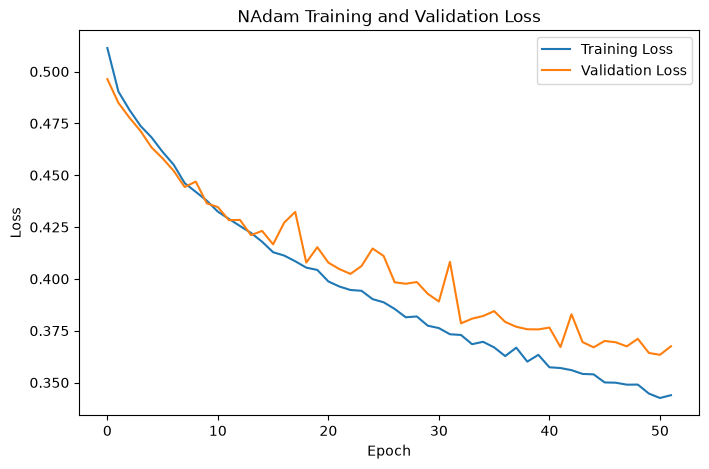

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(
    nadam_train_losses,
    label="Training Loss"
)

plt.plot(
    nadam_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NAdam Training and Validation Loss")

plt.legend()
plt.show()

In [71]:
accuracy = (targets == predictions).mean()

exact_match_accuracy = np.all(
    targets == predictions,
    axis=1
).mean()

print("Label-wise accuracy:", accuracy)
print("Exact-match accuracy:", exact_match_accuracy)

Label-wise accuracy: 0.8664609053497943
Exact-match accuracy: 0.4604938271604938


### VGG16

In [68]:
import torch
import torch.nn as nn
from torchvision import models

In [69]:
vgg16 = models.vgg16(weights="IMAGENET1K_V1")

# Freeze pretrained layers
for param in vgg16.features.parameters():
    param.requires_grad = False

# Replace classifier
vgg16.classifier[6] = nn.Linear(
    vgg16.classifier[6].in_features,
    num_classes
)

vgg16 = vgg16.to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    vgg16.classifier[6].parameters(),
    lr=0.001
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Niraj Mhatre/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [01:09<00:00, 7.97MB/s] 


In [70]:
vgg_train_losses = []
vgg_val_losses = []
vgg_f1s = []

best_vgg_f1 = 0

num_epochs = 10

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        vgg16,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, targets, predictions = validate(
        vgg16,
        val_loader,
        criterion,
        device
    )

    precision, recall, f1 = calculate_metrics(
        targets,
        predictions
    )

    vgg_train_losses.append(train_loss)
    vgg_val_losses.append(val_loss)
    vgg_f1s.append(f1)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

    if f1 > best_vgg_f1:
        best_vgg_f1 = f1

        torch.save(
            vgg16.state_dict(),
            "vgg16_best.pth"
        )

print("Best VGG16 F1:", best_vgg_f1)

Epoch 1/10 | Train Loss: 0.3858 | Val Loss: 0.3160 | Precision: 0.7414 | Recall: 0.6449 | F1: 0.6628
Epoch 2/10 | Train Loss: 0.3240 | Val Loss: 0.3031 | Precision: 0.7957 | Recall: 0.6105 | F1: 0.6676
Epoch 3/10 | Train Loss: 0.3108 | Val Loss: 0.3018 | Precision: 0.7653 | Recall: 0.6353 | F1: 0.6856
Epoch 4/10 | Train Loss: 0.3017 | Val Loss: 0.3008 | Precision: 0.7399 | Recall: 0.6875 | F1: 0.7084
Epoch 5/10 | Train Loss: 0.3048 | Val Loss: 0.2954 | Precision: 0.7492 | Recall: 0.6733 | F1: 0.7060
Epoch 6/10 | Train Loss: 0.2986 | Val Loss: 0.2932 | Precision: 0.7489 | Recall: 0.6796 | F1: 0.7043
Epoch 7/10 | Train Loss: 0.3011 | Val Loss: 0.2942 | Precision: 0.7464 | Recall: 0.7149 | F1: 0.7221
Epoch 8/10 | Train Loss: 0.2965 | Val Loss: 0.2933 | Precision: 0.7672 | Recall: 0.6483 | F1: 0.6857
Epoch 9/10 | Train Loss: 0.2955 | Val Loss: 0.2933 | Precision: 0.7806 | Recall: 0.6409 | F1: 0.6830
Epoch 10/10 | Train Loss: 0.2868 | Val Loss: 0.2891 | Precision: 0.7790 | Recall: 0.6386 | 

In [72]:
resnet50 = models.resnet50(
    weights="IMAGENET1K_V2"
)

# Freeze pretrained layers
for param in resnet50.parameters():
    param.requires_grad = False

# Replace final layer
resnet50.fc = nn.Linear(
    resnet50.fc.in_features,
    num_classes
)

resnet50 = resnet50.to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    resnet50.fc.parameters(),
    lr=0.001
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Niraj Mhatre/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:09<00:00, 10.5MB/s]


In [73]:
resnet_train_losses = []
resnet_val_losses = []
resnet_f1s = []

best_resnet_f1 = 0

num_epochs = 10

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        resnet50,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, targets, predictions = validate(
        resnet50,
        val_loader,
        criterion,
        device
    )

    precision, recall, f1 = calculate_metrics(
        targets,
        predictions
    )

    resnet_train_losses.append(train_loss)
    resnet_val_losses.append(val_loss)
    resnet_f1s.append(f1)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

    if f1 > best_resnet_f1:
        best_resnet_f1 = f1

        torch.save(
            resnet50.state_dict(),
            "resnet50_best.pth"
        )

print("Best ResNet50 F1:", best_resnet_f1)

Epoch 1/10 | Train Loss: 0.4494 | Val Loss: 0.3730 | Precision: 0.7483 | Recall: 0.3528 | F1: 0.4191
Epoch 2/10 | Train Loss: 0.3542 | Val Loss: 0.3303 | Precision: 0.6993 | Recall: 0.5092 | F1: 0.5696
Epoch 3/10 | Train Loss: 0.3222 | Val Loss: 0.3094 | Precision: 0.8451 | Recall: 0.5814 | F1: 0.6454
Epoch 4/10 | Train Loss: 0.3024 | Val Loss: 0.2964 | Precision: 0.8363 | Recall: 0.6167 | F1: 0.6577
Epoch 5/10 | Train Loss: 0.2907 | Val Loss: 0.2924 | Precision: 0.8551 | Recall: 0.5946 | F1: 0.6454
Epoch 6/10 | Train Loss: 0.2834 | Val Loss: 0.2836 | Precision: 0.8219 | Recall: 0.6232 | F1: 0.6714
Epoch 7/10 | Train Loss: 0.2755 | Val Loss: 0.2815 | Precision: 0.8476 | Recall: 0.6216 | F1: 0.6717
Epoch 8/10 | Train Loss: 0.2685 | Val Loss: 0.2871 | Precision: 0.8328 | Recall: 0.6596 | F1: 0.6902
Epoch 9/10 | Train Loss: 0.2620 | Val Loss: 0.2783 | Precision: 0.8059 | Recall: 0.6431 | F1: 0.6964
Epoch 10/10 | Train Loss: 0.2594 | Val Loss: 0.2792 | Precision: 0.8260 | Recall: 0.6313 | 

In [74]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "VGG16",
        "ResNet50"
    ],
    "Best Macro F1": [
        max(nadam_f1s),       # or your best CNN F1
        max(vgg_f1s),
        max(resnet_f1s)
    ]
})

results

,Model,Best Macro F1
0,Custom CNN,0.581998
1,VGG16,0.722138
2,ResNet50,0.696397


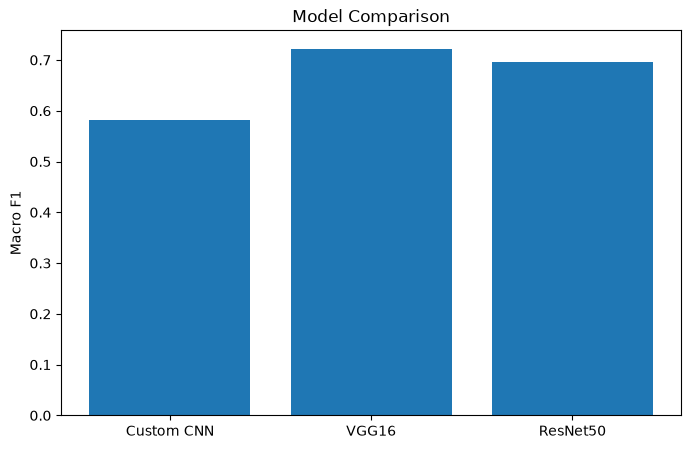

In [75]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Best Macro F1"]
)

plt.ylabel("Macro F1")
plt.title("Model Comparison")

plt.show()

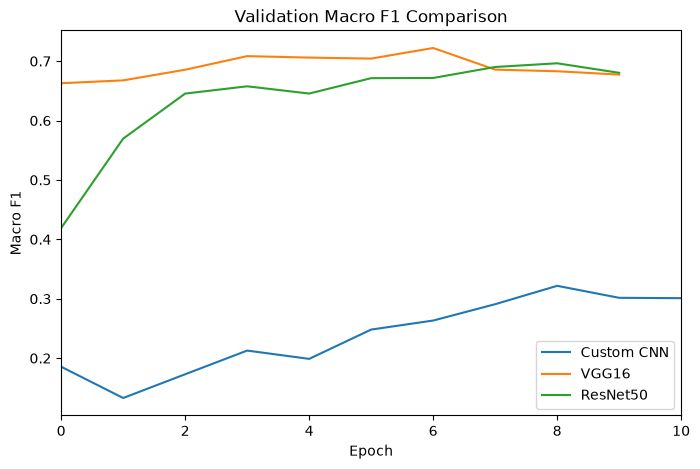

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(
    nadam_f1s,
    label="Custom CNN"
)

plt.plot(
    vgg_f1s,
    label="VGG16"
)

plt.plot(
    resnet_f1s,
    label="ResNet50"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Validation Macro F1 Comparison")
plt.xlim(0,10)
plt.legend()

plt.show()

In [ ]:
resnet50.load_state_dict(
    torch.load(
        "resnet50_best.pth",
        map_location=device
    )
)
model = resnet50

model = model.to(device)

In [80]:
val_loss, targets, predictions = validate(
    model,
    val_loader,
    criterion,
    device
)

precision, recall, f1 = calculate_metrics(
    targets,
    predictions
)

print("Final Precision:", precision)
print("Final Recall:", recall)
print("Final Macro F1:", f1)

Final Precision: 0.8058995253634164
Final Recall: 0.6431077735561576
Final Macro F1: 0.6963969656949937
